# Chapter 63 — Token Embeddings Plus Position Embeddings

## Learning goals

By the end of this chapter, you should be able to:

- Explain why token identity does not explicitly identify a token's location.

- Distinguish token IDs from position IDs.

- Create learned token and absolute position embedding tables.

- Look up token embeddings for a batched token-ID tensor.

- Look up position embeddings for the context positions.

- Broadcast position embeddings across a batch.

- Add token and position embeddings without changing tensor shape.

- Compare addition with concatenation.

- Explain how a learned absolute position table limits direct lookup length.

- Build a validated, reusable token-plus-position embedding module.


## Filling in the input stage

The attention chapters treated input vectors shaped `[batch, context, embedding]` as already available.

This chapter fills in the earlier stage that creates those vectors from token IDs.

A GPT-2-style learned absolute embedding stage adds two vectors at every position:

```text
token embedding + absolute position embedding = transformer input vector
```

The token component represents which vocabulary item appears.

The position component explicitly represents where it appears within the current context.


## Position information is a design choice

Learned absolute position embeddings are one common positional method rather than a requirement of every GPT-style architecture.

Other transformer designs use sinusoidal encodings, relative position biases, rotary position embeddings, or related methods.

A causal mask also supplies directional structure by limiting which positions can communicate.

The learned absolute vectors in this chapter provide each token representation with an explicit trainable location signal.

We focus on this method because its lookup and addition operations are concrete and easy to inspect.


## Same tokens, different order

The sentences `"dog bites man"` and `"man bites dog"` contain the same three token types in different orders.

A token embedding lookup assigns the same vector to `"dog"` wherever it appears.

A position embedding makes the representation for `"dog"` at position `0` different from its representation at position `2`.


The first code cell builds a vocabulary, encodes both sentences, and places them in one batch.


In [1]:
import torch

device = "cpu"
first_sentence_tokens = ["dog", "bites", "man"]
second_sentence_tokens = ["man", "bites", "dog"]
batch_tokens = [first_sentence_tokens, second_sentence_tokens]

vocabulary = sorted(set(first_sentence_tokens + second_sentence_tokens))
token_to_id = {token: token_id for token_id, token in enumerate(vocabulary)}
id_to_token = {token_id: token for token, token_id in token_to_id.items()}

input_token_ids = torch.tensor(
    [[token_to_id[token] for token in sentence] for sentence in batch_tokens],
    dtype=torch.long,
    device=device,
)
batch_size, context_length = input_token_ids.shape

print("device:", device)
print("vocabulary:", vocabulary)
print("token_to_id:", token_to_id)
print("input_token_ids:")
print(input_token_ids)
print("input shape:", input_token_ids.shape)

device: cpu
vocabulary: ['bites', 'dog', 'man']
token_to_id: {'bites': 0, 'dog': 1, 'man': 2}
input_token_ids:
tensor([[1, 0, 2],
        [2, 0, 1]])
input shape: torch.Size([2, 3])


The ID tensor has shape `[batch size, context length]`, or `[2, 3]`.

Both rows contain the same IDs in different positions.

A token ID names a vocabulary item, while the column index identifies that occurrence's position.


## Two embedding tables

A token embedding table has one trainable row per vocabulary item.

A learned absolute position embedding table has one trainable row per supported position.

Both tables use the same embedding dimension because their lookup vectors will be added element by element.

We assign simple weights by hand so that token and position contributions remain visible.


In [2]:
embedding_dimension = 4
vocabulary_size = len(vocabulary)

token_embedding_table = torch.nn.Embedding(
    num_embeddings=vocabulary_size,
    embedding_dim=embedding_dimension,
).to(device)
position_embedding_table = torch.nn.Embedding(
    num_embeddings=context_length,
    embedding_dim=embedding_dimension,
).to(device)

with torch.no_grad():
    token_embedding_table.weight.copy_(
        torch.tensor(
            [
                [1.0, 0.0, 0.0, 0.0],
                [0.0, 1.0, 0.0, 0.0],
                [0.0, 0.0, 1.0, 0.0],
            ],
            device=device,
        )
    )
    position_embedding_table.weight.copy_(
        torch.tensor(
            [
                [0.0, 0.0, 0.0, 0.1],
                [0.0, 0.0, 0.0, 0.2],
                [0.0, 0.0, 0.0, 0.3],
            ],
            device=device,
        )
    )

print("token table shape:", token_embedding_table.weight.shape)
print(token_embedding_table.weight)
print("position table shape:", position_embedding_table.weight.shape)
print(position_embedding_table.weight)

token table shape: torch.Size([3, 4])
Parameter containing:
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]], requires_grad=True)
position table shape: torch.Size([3, 4])
Parameter containing:
tensor([[0.0000, 0.0000, 0.0000, 0.1000],
        [0.0000, 0.0000, 0.0000, 0.2000],
        [0.0000, 0.0000, 0.0000, 0.3000]], requires_grad=True)


The token table shape is `[vocabulary size, embedding dimension]`, or `[3, 4]`.

The position table shape is `[maximum context length, embedding dimension]`, also `[3, 4]` here.

The simple values place token identity in the first three components and absolute position in the final component.

A trained model is free to distribute both kinds of information across all components.


## Look up and add the vectors

Passing the batched token IDs through the token table produces `[batch, context, embedding]`.

The position IDs are the integers from `0` through `context length - 1`, shared by every batch item.

Their lookup has shape `[context, embedding]` and broadcasts across the missing batch axis during addition.


In [3]:
token_embeddings = token_embedding_table(input_token_ids)
position_ids = torch.arange(context_length, dtype=torch.long, device=device)
position_embeddings = position_embedding_table(position_ids)
combined_embeddings = token_embeddings + position_embeddings

explicit_position_embeddings = position_embeddings.unsqueeze(dim=0)
explicit_combined_embeddings = token_embeddings + explicit_position_embeddings

print("token ID shape:", input_token_ids.shape)
print("token embedding shape:", token_embeddings.shape)
print("position ID shape:", position_ids.shape)
print("position embedding shape:", position_embeddings.shape)
print("explicit broadcast shape:", explicit_position_embeddings.shape)
print("combined embedding shape:", combined_embeddings.shape)
print(
    "implicit and explicit broadcasting match:",
    torch.allclose(combined_embeddings, explicit_combined_embeddings),
)

token ID shape: torch.Size([2, 3])
token embedding shape: torch.Size([2, 3, 4])
position ID shape: torch.Size([3])
position embedding shape: torch.Size([3, 4])
explicit broadcast shape: torch.Size([1, 3, 4])
combined embedding shape: torch.Size([2, 3, 4])
implicit and explicit broadcasting match: True


Broadcasting treats `[T, C]` position embeddings as `[1, T, C]` and reuses them for all `B` sequences.

Addition preserves the desired transformer input shape `[B, T, C]`, or `[2, 3, 4]`.


The full labeled table separates the two contributions at every batch position.


In [4]:
print(
    "batch | position | token | token embedding      | "
    "position embedding   | combined embedding"
)
print("-" * 108)
for batch_index, tokens in enumerate(batch_tokens):
    for position, token in enumerate(tokens):
        print(
            f"{batch_index:>5} | {position:>8} | {token:>5} | "
            f"{str(token_embeddings[batch_index, position].tolist()):>20} | "
            f"{str(position_embeddings[position].tolist()):>20} | "
            f"{combined_embeddings[batch_index, position].tolist()}"
        )

batch | position | token | token embedding      | position embedding   | combined embedding
------------------------------------------------------------------------------------------------------------
    0 |        0 |   dog | [0.0, 1.0, 0.0, 0.0] | [0.0, 0.0, 0.0, 0.10000000149011612] | [0.0, 1.0, 0.0, 0.10000000149011612]
    0 |        1 | bites | [1.0, 0.0, 0.0, 0.0] | [0.0, 0.0, 0.0, 0.20000000298023224] | [1.0, 0.0, 0.0, 0.20000000298023224]
    0 |        2 |   man | [0.0, 0.0, 1.0, 0.0] | [0.0, 0.0, 0.0, 0.30000001192092896] | [0.0, 0.0, 1.0, 0.30000001192092896]
    1 |        0 |   man | [0.0, 0.0, 1.0, 0.0] | [0.0, 0.0, 0.0, 0.10000000149011612] | [0.0, 0.0, 1.0, 0.10000000149011612]
    1 |        1 | bites | [1.0, 0.0, 0.0, 0.0] | [0.0, 0.0, 0.0, 0.20000000298023224] | [1.0, 0.0, 0.0, 0.20000000298023224]
    1 |        2 |   dog | [0.0, 1.0, 0.0, 0.0] | [0.0, 0.0, 0.0, 0.30000001192092896] | [0.0, 1.0, 0.0, 0.30000001192092896]


Every row satisfies `combined = token + position`.

The same position vector is reused down a context column, while the token vector follows token identity.


## Hold one factor constant

The token `"dog"` appears at position `0` in the first sentence and position `2` in the second sentence.

Its token embedding stays fixed while its position and combined embeddings change.

Position `0` provides the complementary comparison because it uses one position embedding with two different token embeddings.


In [5]:
dog_id = token_to_id["dog"]
dog_locations = (input_token_ids == dog_id).nonzero(as_tuple=False)

print("Same token at different positions")
for batch_index, position in dog_locations.tolist():
    print(
        f"batch {batch_index}, position {position}: "
        f"token={token_embeddings[batch_index, position].tolist()}, "
        f"position={position_embeddings[position].tolist()}, "
        f"combined={combined_embeddings[batch_index, position].tolist()}"
    )

print("\nSame position with different tokens")
for batch_index in range(batch_size):
    token_id = input_token_ids[batch_index, 0].item()
    print(
        f"batch {batch_index}, token {id_to_token[token_id]!r}: "
        f"token={token_embeddings[batch_index, 0].tolist()}, "
        f"position={position_embeddings[0].tolist()}, "
        f"combined={combined_embeddings[batch_index, 0].tolist()}"
    )

Same token at different positions
batch 0, position 0: token=[0.0, 1.0, 0.0, 0.0], position=[0.0, 0.0, 0.0, 0.10000000149011612], combined=[0.0, 1.0, 0.0, 0.10000000149011612]
batch 1, position 2: token=[0.0, 1.0, 0.0, 0.0], position=[0.0, 0.0, 0.0, 0.30000001192092896], combined=[0.0, 1.0, 0.0, 0.30000001192092896]

Same position with different tokens
batch 0, token 'dog': token=[0.0, 1.0, 0.0, 0.0], position=[0.0, 0.0, 0.0, 0.10000000149011612], combined=[0.0, 1.0, 0.0, 0.10000000149011612]
batch 1, token 'man': token=[0.0, 0.0, 1.0, 0.0], position=[0.0, 0.0, 0.0, 0.10000000149011612], combined=[0.0, 0.0, 1.0, 0.10000000149011612]


These comparisons show that token and position tables answer different lookup questions.

Token IDs and position IDs can have the same integer value while referring to different tables and meanings.


## Why this design uses addition

Adding two width-`C` vectors produces another width-`C` vector that can enter the transformer without changing its expected feature size.

Concatenating the same vectors produces width `2C` and would require downstream layers or an extra projection to accept that larger representation.

Concatenation is not invalid in principle, but it is not the learned absolute embedding design implemented here.


In [6]:
broadcast_position_embeddings = explicit_position_embeddings.expand_as(token_embeddings)
added_embeddings = token_embeddings + broadcast_position_embeddings
concatenated_embeddings = torch.cat(
    [token_embeddings, broadcast_position_embeddings], dim=-1
)

print("token shape:", token_embeddings.shape)
print("broadcast position shape:", broadcast_position_embeddings.shape)
print("added shape:", added_embeddings.shape)
print("concatenated shape:", concatenated_embeddings.shape)
print(
    "embedding dimensions match for addition:",
    token_embeddings.shape[-1] == position_embeddings.shape[-1],
)

token shape: torch.Size([2, 3, 4])
broadcast position shape: torch.Size([2, 3, 4])
added shape: torch.Size([2, 3, 4])
concatenated shape: torch.Size([2, 3, 8])
embedding dimensions match for addition: True


Addition keeps shape `[2, 3, 4]`, whereas concatenation changes it to `[2, 3, 8]`.

Elementwise addition requires the token and position embedding dimensions to match.


The following figure visualizes the addition for the first sentence.


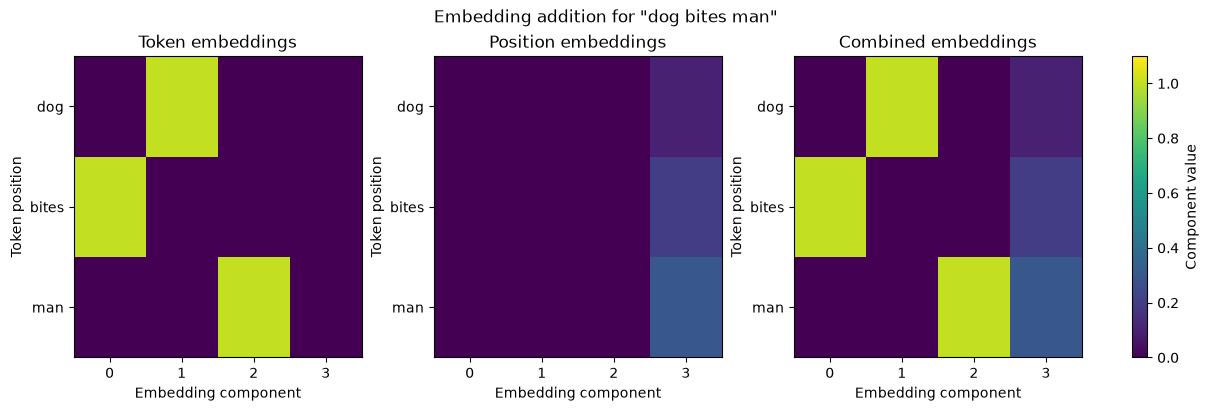

In [7]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
matrices = [
    token_embeddings[0].detach(),
    position_embeddings.detach(),
    combined_embeddings[0].detach(),
]
titles = ["Token embeddings", "Position embeddings", "Combined embeddings"]

for axis, matrix, title in zip(axes, matrices, titles, strict=True):
    image = axis.imshow(matrix, aspect="auto", vmin=0.0, vmax=1.1)
    axis.set_xticks(range(embedding_dimension))
    axis.set_yticks(range(context_length), first_sentence_tokens)
    axis.set_xlabel("Embedding component")
    axis.set_ylabel("Token position")
    axis.set_title(title)

figure.colorbar(image, ax=axes, label="Component value")
figure.suptitle('Embedding addition for "dog bites man"')
plt.show()

The combined panel contains the token-specific components from the first panel and the position-specific final component from the second.

Real learned embeddings are dense, so their components will not separate this neatly.


## Learned absolute positions set a lookup limit

A learned position table with `T_max` rows directly supports IDs from `0` through `T_max - 1`.

A longer sequence needs a larger or adapted table, or a positional method designed for that situation.

The reusable module below names this capacity `maximum_context_length` and rejects longer inputs before lookup.


## A reusable embedding module

The module validates tensor rank, integer dtype, nonempty dimensions, token-ID range, and maximum context length.

Its inspection method returns both components along with their sum.


In [8]:
class TokenAndPositionEmbedding(torch.nn.Module):
    vocabulary_size: int
    maximum_context_length: int
    embedding_dimension: int
    token_embedding_table: torch.nn.Embedding
    position_embedding_table: torch.nn.Embedding

    def __init__(
        self,
        vocabulary_size: int,
        maximum_context_length: int,
        embedding_dimension: int,
    ) -> None:
        super().__init__()

        if vocabulary_size < 1 or maximum_context_length < 1 or embedding_dimension < 1:
            raise ValueError("all dimensions must be positive.")

        self.vocabulary_size = vocabulary_size
        self.maximum_context_length = maximum_context_length
        self.embedding_dimension = embedding_dimension
        self.token_embedding_table = torch.nn.Embedding(
            vocabulary_size, embedding_dimension
        )
        self.position_embedding_table = torch.nn.Embedding(
            maximum_context_length, embedding_dimension
        )

    def components(
        self, input_token_ids: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        if input_token_ids.ndim != 2:
            raise ValueError("input IDs must have shape [batch, context].")

        if input_token_ids.dtype not in (torch.int32, torch.int64):
            raise TypeError("input IDs must use an integer dtype.")

        current_batch_size, current_context_length = input_token_ids.shape
        if current_batch_size < 1 or current_context_length < 1:
            raise ValueError("batch size and context length must be positive.")

        if current_context_length > self.maximum_context_length:
            raise ValueError("input exceeds the maximum context length.")

        if torch.any(input_token_ids < 0) or torch.any(
            input_token_ids >= self.vocabulary_size
        ):
            raise ValueError("input contains an out-of-range token ID.")

        token_embeddings = self.token_embedding_table(input_token_ids)
        position_ids = torch.arange(
            current_context_length,
            dtype=torch.long,
            device=input_token_ids.device,
        )
        position_embeddings = self.position_embedding_table(position_ids)
        combined_embeddings = token_embeddings + position_embeddings
        return token_embeddings, position_embeddings, combined_embeddings

    def forward(self, input_token_ids: torch.Tensor) -> torch.Tensor:
        _, _, combined_embeddings = self.components(input_token_ids)
        return combined_embeddings


torch.manual_seed(63)
embedding_module = TokenAndPositionEmbedding(
    vocabulary_size=vocabulary_size,
    maximum_context_length=5,
    embedding_dimension=embedding_dimension,
).to(device)

module_token_embeddings, module_position_embeddings, module_output = (
    embedding_module.components(input_token_ids)
)
shorter_output = embedding_module(input_token_ids[:, :2])

print("module token shape:", module_token_embeddings.shape)
print("module position shape:", module_position_embeddings.shape)
print("module output shape:", module_output.shape)
print("shorter output shape:", shorter_output.shape)
print("configured maximum context length:", end=" ")
print(embedding_module.maximum_context_length)

module token shape: torch.Size([2, 3, 4])
module position shape: torch.Size([3, 4])
module output shape: torch.Size([2, 3, 4])
shorter output shape: torch.Size([2, 2, 4])
configured maximum context length: 5


The same module handles any positive context length up to its configured maximum.

Its output always has shape `[batch, current context, embedding dimension]`.


Both tables are trainable parameters, and their combined parameter count follows directly from their row counts.


In [9]:
expected_parameter_count = (
    embedding_module.vocabulary_size * embedding_module.embedding_dimension
    + embedding_module.maximum_context_length * embedding_module.embedding_dimension
)
actual_parameter_count = sum(
    parameter.numel() for parameter in embedding_module.parameters()
)

print("named parameters:")
for name, parameter in embedding_module.named_parameters():
    print(name, parameter.shape, "requires_grad=", parameter.requires_grad)
print("expected parameter count:", expected_parameter_count)
print("actual parameter count:", actual_parameter_count)
print("counts match:", expected_parameter_count == actual_parameter_count)
print(
    "length 5 is supported:",
    embedding_module.maximum_context_length >= 5,
)
print(
    "length 6 is supported:",
    embedding_module.maximum_context_length >= 6,
)

named parameters:
token_embedding_table.weight torch.Size([3, 4]) requires_grad= True
position_embedding_table.weight torch.Size([5, 4]) requires_grad= True
expected parameter count: 32
actual parameter count: 32
counts match: True
length 5 is supported: True
length 6 is supported: False


The token table contributes `vocabulary size × embedding dimension` parameters.

The position table contributes `maximum context length × embedding dimension` parameters.

Both `weight` tensors require gradients and will be updated during training.


## Shape summary

| Tensor or table | Shape | Example |
|---|---:|---:|
| Input token IDs | `B × T` | `2 × 3` |
| Token embedding table | `V × C` | `3 × 4` |
| Position embedding table | `T_max × C` | `3 × 4` |
| Token embeddings | `B × T × C` | `2 × 3 × 4` |
| Position IDs | `T` | `3` |
| Position embeddings | `T × C` | `3 × 4` |
| Combined embeddings | `B × T × C` | `2 × 3 × 4` |

`B` is batch size, `T` is current context length, `T_max` is table capacity, `V` is vocabulary size, and `C` is embedding dimension.


## Common mistakes

- **Confusing IDs:** token IDs index the vocabulary table, while position IDs index the position table.

- **Claiming token embeddings contain location:** the same token ID always selects the same token-table row.

- **Using mismatched widths:** elementwise addition requires both embedding tables to output dimension `C`.

- **Concatenating by accident:** concatenation changes the feature width and is not this learned absolute embedding design.

- **Building position IDs per batch unnecessarily:** one `[T]` range broadcasts across all batch items.

- **Exceeding table capacity:** direct learned-position lookup cannot use an ID without a table row.

- **Calling learned absolute embeddings universal:** modern transformer families use several different positional mechanisms.


## Takeaways

- Token embeddings represent vocabulary identity, and learned absolute position embeddings represent context location.

- Position IDs run from `0` through the current context length minus one.

- One `[T, C]` position lookup broadcasts across token embeddings shaped `[B, T, C]`.

- Addition preserves shape `[B, T, C]`, while concatenation changes feature width.

- The same token at two positions receives two different combined vectors.

- A learned absolute position table has a configured direct-lookup capacity `T_max`.

- Token and position tables are both trainable model parameters.

> The combined embedding supplies token identity and an explicit learned location signal in one width-`C` vector.


## What comes next

The combined embeddings now provide the concrete `[B, T, C]` input used by the attention chapters.

The next chapter continues assembling a transformer block by introducing the position-wise feedforward network that follows attention.
